In [21]:
### CITATIONS ###
# I read through and utilized the following references to help me understand and set up the neural network. #
# https://medium.com/@a.r.amouzad.m/how-to-get-state-of-the-art-result-on-graph-classification-with-gnn-73afadff5d49
# https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb
# https://blog.dataiku.com/graph-neural-networks-part-three

In [1]:
#!pip install torch
#!pip install torch_geometric

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, f1_score
import numpy as np
import time
import random
import networkx as nx
import optuna
from optuna.samplers import TPESampler
from gwgraphs import *
from visualizations import GCNResultsVisualizer, get_model_probabilities

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
def read_graph_data():
  # Read the adjacency matrix (edges)
  with open("IMDB-BINARY_A.txt", "r") as f:
    edges = [tuple(map(int, line.split(','))) for line in f]

  # Read graph indicators
  with open("IMDB-BINARY_graph_indicator.txt", "r") as f:
    graph_indicators = [int(line.strip()) for line in f if line.strip()]

  # Read graph labels
  with open("IMDB-BINARY_graph_labels.txt", "r") as f:
    graph_labels = [int(line.strip()) for line in f]

  return edges, graph_indicators, graph_labels


def construct_networkx_graph(edges, graph_indicators, graph_labels):
  graphs = {}
  for node_id, graph_id in enumerate(graph_indicators, start=1):
    if graph_id not in graphs:
      graphs[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])

  for edge in edges:
    node1, node2 = edge
    graph_id = graph_indicators[node1 -
                                1]  # Determine which graph the edge belongs to
    graphs[graph_id].add_edge(node1, node2)

  return graphs


def compute_distance_matrix(graph):
  num_nodes = len(graph.nodes)
  distance_matrix = np.full((num_nodes, num_nodes), 10000.0)

  # Get the correct node indices to be used for indexing the matrix
  node_list = list(graph.nodes())
  node_index = {node: i for i, node in enumerate(node_list)}

  for node in graph.nodes:
    lengths = nx.shortest_path_length(graph, source=node, weight="weight")

    for target, length in lengths.items():
      if target in node_index:
        distance_matrix[node_index[node], node_index[target]] = length

  return distance_matrix


class GraphNeuralNetwork(nn.Module):

  def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3):
    super(GraphNeuralNetwork, self).__init__()

    self.num_layers = num_layers
    self.convs = nn.ModuleList()

    # First layer
    self.convs.append(GCNConv(input_dim, hidden_dim))

    # Hidden layers
    for _ in range(num_layers - 2):
      self.convs.append(GCNConv(hidden_dim, hidden_dim))

    # Last layer
    self.convs.append(GCNConv(hidden_dim, hidden_dim))

    # Classifier
    self.classifier = nn.Linear(hidden_dim, output_dim)
    self.dropout = nn.Dropout(0.5)

  def forward(self, x, edge_index, batch, edge_attr=None):
    # Apply GCN layers
    for i, conv in enumerate(self.convs):
      x = conv(x, edge_index, edge_weight=edge_attr)
      if i < len(self.convs) - 1:
        x = F.relu(x)
        x = self.dropout(x)

    # Global pooling to get graph-level representation
    x = global_mean_pool(x, batch)

    # Final classification
    x = self.classifier(x)

    return x


def train_model(model, train_loader, optimizer, criterion, device):
  """Function to train the model for one epoch."""
  model.train()
  total_loss = 0

  for batch in train_loader:
    batch = batch.to(device)
    optimizer.zero_grad()

    # Forward pass
    out = model(batch.x, batch.edge_index, batch.batch,
                batch.edge_attr if hasattr(batch, 'edge_attr') else None)

    # Labels are already {0, 1} for cross-entropy loss
    labels = batch.y

    loss = criterion(out, labels.view(-1))
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(train_loader)


def evaluate_model(model, test_loader, device):
  """Function to evaluate the model."""
  model.eval()
  predictions = []
  true_labels = []

  with torch.no_grad():
    for batch in test_loader:
      batch = batch.to(device)
      out = model(batch.x, batch.edge_index, batch.batch,
                  batch.edge_attr if hasattr(batch, 'edge_attr') else None)

      # Get predictions
      pred = torch.argmax(out, dim=1)
      # Labels are already {0, 1}

      predictions.extend(pred.cpu().numpy())
      true_labels.extend(batch.y.cpu().numpy())

    return np.array(predictions), np.array(true_labels)


def calculate_metrics(y_true, y_pred):
  """Calculate classification metrics"""
  # Overall accuracy
  overall_acc = accuracy_score(y_true, y_pred)

  # By-class accuracy
  class_1_mask = y_true == 1
  class_0_mask = y_true == 0

  class_1_acc = accuracy_score(
      y_true[class_1_mask],
      y_pred[class_1_mask]) if np.sum(class_1_mask) > 0 else 0
  class_0_acc = accuracy_score(
      y_true[class_0_mask],
      y_pred[class_0_mask]) if np.sum(class_0_mask) > 0 else 0

  # F1 score
  f1 = f1_score(y_true, y_pred, average='weighted')

  return overall_acc, class_1_acc, class_0_acc, f1


def networkx_to_pyg(nx_graph, label, num_features):
  """Convert NetworkX graph to PyTorch Geometric Data object with edge features"""
  num_nodes = len(nx_graph.nodes)

  if num_features == 0:
    raise ValueError(
        "num_features cannot be 0. Use num_features=1 for minimal features.")
  elif num_features == 1:
    # Use constant features (all ones) for graphs without meaningful node features
    x = torch.ones(num_nodes, 1)
  else:
    # Create random node features for synthetic examples
    x = torch.randn(num_nodes, num_features)

  # Create a mapping from original node IDs to sequential indices
  nodes = list(nx_graph.nodes())
  node_mapping = {node: i for i, node in enumerate(nodes)}

  # Convert edges to tensor format and create edge features
  edge_list = list(nx_graph.edges())
  if len(edge_list) == 0:
    # Handle graphs with no edges
    edge_index = torch.empty((2, 0), dtype=torch.long)
    edge_attr = torch.empty((0, 1), dtype=torch.float)
  else:
    # Remap edges to use sequential node indices
    remapped_edges = [(node_mapping[u], node_mapping[v]) for u, v in edge_list]
    edge_index = torch.tensor(remapped_edges,
                              dtype=torch.long).t().contiguous()

    # Create edge features based on graph properties
    edge_features = []
    for u, v in edge_list:
      # Use degree difference as edge feature
      degree_diff = abs(nx_graph.degree[u] - nx_graph.degree[v])
      edge_features.append([degree_diff])

    edge_attr = torch.tensor(edge_features, dtype=torch.float)

  # Convert label to tensor
  y = torch.tensor([label], dtype=torch.long)

  return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


def objective(trial, full_graph_data, labels, device, input_dim, hidden_dim,
              output_dim):
  """Objective function for Bayesian optimization"""
  # Suggest hyperparameters
  num_epochs = trial.suggest_int('num_epochs', 20, 100, step=10)
  learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True)
  batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

  # 5-fold cross validation for this trial
  kfold = KFold(n_splits=10, shuffle=True, random_state=42)
  fold_scores = []

  for fold, (train_idx,
             test_idx) in enumerate(kfold.split(full_graph_data, labels)):
    # Split data
    train_graphs = [full_graph_data[i] for i in train_idx]
    test_graphs = [full_graph_data[i] for i in test_idx]

    # Create data loaders
    train_loader = DataLoader(train_graphs,
                              batch_size=batch_size,
                              shuffle=True)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(num_epochs):
      train_loss = train_model(model, train_loader, optimizer, criterion,
                               device)

    # Evaluation
    y_pred, y_true = evaluate_model(model, test_loader, device)
    overall_acc, _, _, _ = calculate_metrics(y_true, y_pred)
    fold_scores.append(overall_acc)

    # Report intermediate objective value for pruning
    trial.report(np.mean(fold_scores[:fold + 1]), fold)

    # Handle pruning based on the intermediate value
    if trial.should_prune():
      raise optuna.exceptions.TrialPruned()

  return np.mean(fold_scores)


def compute_averages(graphs):
  # Initialize variables
  total_nodes = 0
  class_nodes = {}
  class_counts = {}
  # Iterate through graphs to compute totals
  for graph_id, graph in graphs.items():
    num_nodes = graph.number_of_nodes()
    total_nodes += num_nodes

    # Get the class label for the current graph
    graph_label = graph.graph['label']

    if graph_label not in class_nodes:
      class_nodes[graph_label] = 0
      class_counts[graph_label] = 0

    class_nodes[graph_label] += num_nodes
    class_counts[graph_label] += 1
  # Calculate total average
  total_avg = round(total_nodes / len(graphs))

  # Calculate class-based averages
  class_averages = {
      label: round(class_nodes[label] / count)
      for label, count in class_counts.items()
  }

  return total_avg, class_averages

In [4]:
edges, graph_indicators, graph_labels = read_graph_data()
graphs = construct_networkx_graph(edges, graph_indicators, graph_labels)
for graph_id, graph in graphs.items():
  print(
      f"Graph ID: {graph_id}, number of nodes: {graph.number_of_nodes()}, label: {graph.graph['label']}"
  )
total_avg, class_averages = compute_averages(graphs)
print(f"Average number of nodes in entire dataset: {total_avg}")
print("Average number of nodes for each class:")
for class_label, avg_nodes in class_averages.items():
  print(f"  Class {class_label}: {avg_nodes}")

Graph ID: 1, number of nodes: 20, label: 0
Graph ID: 2, number of nodes: 32, label: 0
Graph ID: 3, number of nodes: 21, label: 0
Graph ID: 4, number of nodes: 35, label: 0
Graph ID: 5, number of nodes: 14, label: 0
Graph ID: 6, number of nodes: 63, label: 0
Graph ID: 7, number of nodes: 12, label: 0
Graph ID: 8, number of nodes: 15, label: 0
Graph ID: 9, number of nodes: 18, label: 0
Graph ID: 10, number of nodes: 12, label: 0
Graph ID: 11, number of nodes: 12, label: 0
Graph ID: 12, number of nodes: 20, label: 0
Graph ID: 13, number of nodes: 13, label: 0
Graph ID: 14, number of nodes: 20, label: 0
Graph ID: 15, number of nodes: 72, label: 0
Graph ID: 16, number of nodes: 20, label: 0
Graph ID: 17, number of nodes: 18, label: 0
Graph ID: 18, number of nodes: 12, label: 0
Graph ID: 19, number of nodes: 19, label: 0
Graph ID: 20, number of nodes: 46, label: 0
Graph ID: 21, number of nodes: 30, label: 0
Graph ID: 22, number of nodes: 24, label: 0
Graph ID: 23, number of nodes: 22, label:

In [5]:
graphs_list = []
labels_list = []
for graph_id, graph in graphs.items():
  # Add the graph object to the list
  graphs_list.append(graph)

  # Extract the label and add to the label list
  label = graph.graph['label']
  labels_list.append(label)

# Convert graphs into pairwise distance matrices
distance_matrices = [compute_distance_matrix(graph) for graph in graphs_list]

In [6]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model parameters
input_dim = 1  # Number of node features; no meaningful features in this synthetic example, so set = 1
hidden_dim = 64  # defines the number of neurons in the GCN layers. Essentially, controls the width of the neural network
# larger hidden_dim means more capacity but more parameters
output_dim = 2  # Binary classification, so set to 2

# Generate and process data
# Convert NetworkX graphs to PyTorch Geometric Data objects
full_graph_data = []
graphs_list = []
labels_list = []
for graph_id, nx_graph in graphs.items():
  label = nx_graph.graph['label']
  pyg_data = networkx_to_pyg(nx_graph, label, input_dim)
  full_graph_data.append(pyg_data)
  graphs_list.append(nx_graph)
  labels_list.append(label)

# Extract labels for reference
labels = [data.y.item() for data in full_graph_data]
labels = np.array(labels)
print("IMDB-B dataset processed successfully.")

print("\nStarting Bayesian Optimization for Hyperparameter Tuning...")
start_time = time.time()

# Create Optuna study
study = optuna.create_study(direction='maximize',
                            sampler=TPESampler(seed=42),
                            pruner=optuna.pruners.MedianPruner(
                                n_startup_trials=5, n_warmup_steps=2))

# Optimize hyperparameters
study.optimize(lambda trial: objective(trial, full_graph_data, labels, device,
                                       input_dim, hidden_dim, output_dim),
               n_trials=50)

optimization_time = time.time() - start_time

# Print best hyperparameters
print("\n" + "=" * 60)
print("BAYESIAN OPTIMIZATION RESULTS")
print("=" * 60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best accuracy: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in study.best_trial.params.items():
  print(f"  {key}: {value}")

print(f"\nOptimization time: {optimization_time:.2f} seconds")

# Train final model with best hyperparameters
print("\n" + "=" * 60)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("=" * 60)

best_params = study.best_trial.params
final_num_epochs = best_params['num_epochs']
final_learning_rate = best_params['learning_rate']
final_batch_size = best_params['batch_size']

# 5-fold cross validation with best parameters
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
all_results = []

for fold, (train_idx,
           test_idx) in enumerate(kfold.split(full_graph_data, labels)):
  print(f"\n--- Final Training Fold {fold + 1}/10 ---")

  # Split data
  train_graphs = [full_graph_data[i] for i in train_idx]
  test_graphs = [full_graph_data[i] for i in test_idx]

  # Create data loaders
  train_loader = DataLoader(train_graphs,
                            batch_size=final_batch_size,
                            shuffle=True)
  test_loader = DataLoader(test_graphs,
                           batch_size=final_batch_size,
                           shuffle=False)

  # Initialize model
  model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
  optimizer = optim.Adam(model.parameters(), lr=final_learning_rate)
  criterion = nn.CrossEntropyLoss()

  # Training loop
  for epoch in range(final_num_epochs):
    train_loss = train_model(model, train_loader, optimizer, criterion, device)

    if (epoch + 1) % 10 == 0:
      print(f"Epoch {epoch + 1}/{final_num_epochs}, Loss: {train_loss:.4f}")

  # Final evaluation
  y_pred, y_true = evaluate_model(model, test_loader, device)
  overall_acc, class_1_acc, class_0_acc, f1 = calculate_metrics(
      y_true, y_pred)

  results = {
      'fold': fold + 1,
      'overall_accuracy': overall_acc,
      'class_1_accuracy': class_1_acc,
      'class_0_accuracy': class_0_acc,
      'f1_score': f1
  }

  all_results.append(results)

  print(f"Results for Fold {fold + 1}:")
  print(f"  Overall Accuracy: {overall_acc:.4f}")
  print(f"  Class 1 Accuracy: {class_1_acc:.4f}")
  print(f"  Class 0 Accuracy: {class_0_acc:.4f}")
  print(f"  F1 Score: {f1:.4f}")

# Calculate final average metrics
avg_overall_acc = np.mean([r['overall_accuracy'] for r in all_results])
avg_class_1_acc = np.mean([r['class_1_accuracy'] for r in all_results])
avg_class_0_acc = np.mean([r['class_0_accuracy'] for r in all_results])
avg_f1 = np.mean([r['f1_score'] for r in all_results])

std_overall_acc = np.std([r['overall_accuracy'] for r in all_results])
std_class_1_acc = np.std([r['class_1_accuracy'] for r in all_results])
std_class_0_acc = np.std([r['class_0_accuracy'] for r in all_results])
std_f1 = np.std([r['f1_score'] for r in all_results])

total_time = time.time() - start_time

print("\n" + "=" * 60)
print("FINAL RESULTS WITH OPTIMIZED HYPERPARAMETERS")
print("=" * 60)
print(f"Best hyperparameters used:")
print(f"  Epochs: {final_num_epochs}")
print(f"  Learning Rate: {final_learning_rate:.6f}")
print(f"  Batch Size: {final_batch_size}")
print(f"\nFinal Cross-Validation Results:")
print(
    f"Average Overall Accuracy: {avg_overall_acc:.4f} ± {std_overall_acc:.4f}")
print(
    f"Average Class 1 Accuracy: {avg_class_1_acc:.4f} ± {std_class_1_acc:.4f}")
print(
    f"Average Class 0 Accuracy: {avg_class_0_acc:.4f} ± {std_class_0_acc:.4f}")
print(f"Average F1 Score: {avg_f1:.4f} ± {std_f1:.4f}")
print(
    f"\nTotal Time (Optimization + Final Training): {total_time:.2f} seconds")

[I 2025-07-30 18:32:07,449] A new study created in memory with name: no-name-12c2247e-956a-45a6-b4e5-a6503fd3c187


Using device: cpu
IMDB-B dataset processed successfully.

Starting Bayesian Optimization for Hyperparameter Tuning...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader


BAYESIAN OPTIMIZATION RESULTS
Best trial: 14
Best accuracy: 0.6070
Best hyperparameters:
  num_epochs: 80
  learning_rate: 0.0010872847867193325
  batch_size: 32

Optimization time: 3072.46 seconds

TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

--- Final Training Fold 1/10 ---
Epoch 10/80, Loss: 0.6934
Epoch 20/80, Loss: 0.6943
Epoch 30/80, Loss: 0.6899
Epoch 40/80, Loss: 0.6860
Epoch 50/80, Loss: 0.6682
Epoch 60/80, Loss: 0.6603
Epoch 70/80, Loss: 0.6749
Epoch 80/80, Loss: 0.6659
Results for Fold 1:
  Overall Accuracy: 0.6100
  Class 1 Accuracy: 0.7308
  Class 0 Accuracy: 0.4792
  F1 Score: 0.6034

--- Final Training Fold 2/10 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


...

Epoch 10/80, Loss: 0.6900
Epoch 20/80, Loss: 0.6923
Epoch 30/80, Loss: 0.6868
Epoch 40/80, Loss: 0.6804
Epoch 50/80, Loss: 0.6612
Epoch 60/80, Loss: 0.6610
Epoch 70/80, Loss: 0.6553
Epoch 80/80, Loss: 0.6603
Results for Fold 8:
  Overall Accuracy: 0.6000
  Class 1 Accuracy: 0.6000
  Class 0 Accuracy: 0.6000
  F1 Score: 0.6039

--- Final Training Fold 9/10 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 10/80, Loss: 0.6956
Epoch 20/80, Loss: 0.6917
Epoch 30/80, Loss: 0.6895
Epoch 40/80, Loss: 0.6731
Epoch 50/80, Loss: 0.6646
Epoch 60/80, Loss: 0.6641
Epoch 70/80, Loss: 0.6617
Epoch 80/80, Loss: 0.6606
Results for Fold 9:
  Overall Accuracy: 0.5400
  Class 1 Accuracy: 0.6182
  Class 0 Accuracy: 0.4444
  F1 Score: 0.5374

--- Final Training Fold 10/10 ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 10/80, Loss: 0.6926
Epoch 20/80, Loss: 0.6938
Epoch 30/80, Loss: 0.6936
Epoch 40/80, Loss: 0.6933
Epoch 50/80, Loss: 0.6862
Epoch 60/80, Loss: 0.6784
Epoch 70/80, Loss: 0.6693
Epoch 80/80, Loss: 0.6647
Results for Fold 10:
  Overall Accuracy: 0.6500
  Class 1 Accuracy: 0.8409
  Class 0 Accuracy: 0.5000
  F1 Score: 0.6433

FINAL RESULTS WITH OPTIMIZED HYPERPARAMETERS
Best hyperparameters used:
  Epochs: 80
  Learning Rate: 0.001087
  Batch Size: 32

Final Cross-Validation Results:
Average Overall Accuracy: 0.5780 ± 0.0402
Average Class 1 Accuracy: 0.6426 ± 0.1073
Average Class 0 Accuracy: 0.5204 ± 0.0718
Average F1 Score: 0.5753 ± 0.0403

Total Time (Optimization + Final Training): 3152.03 seconds


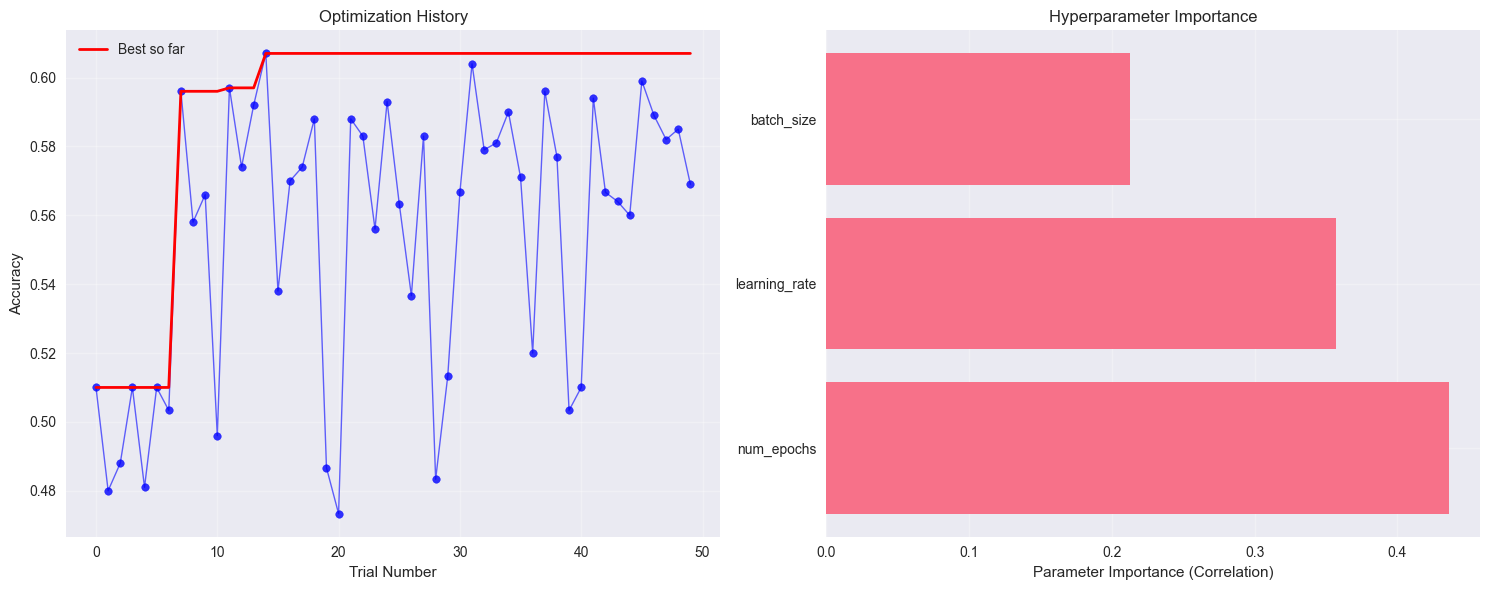

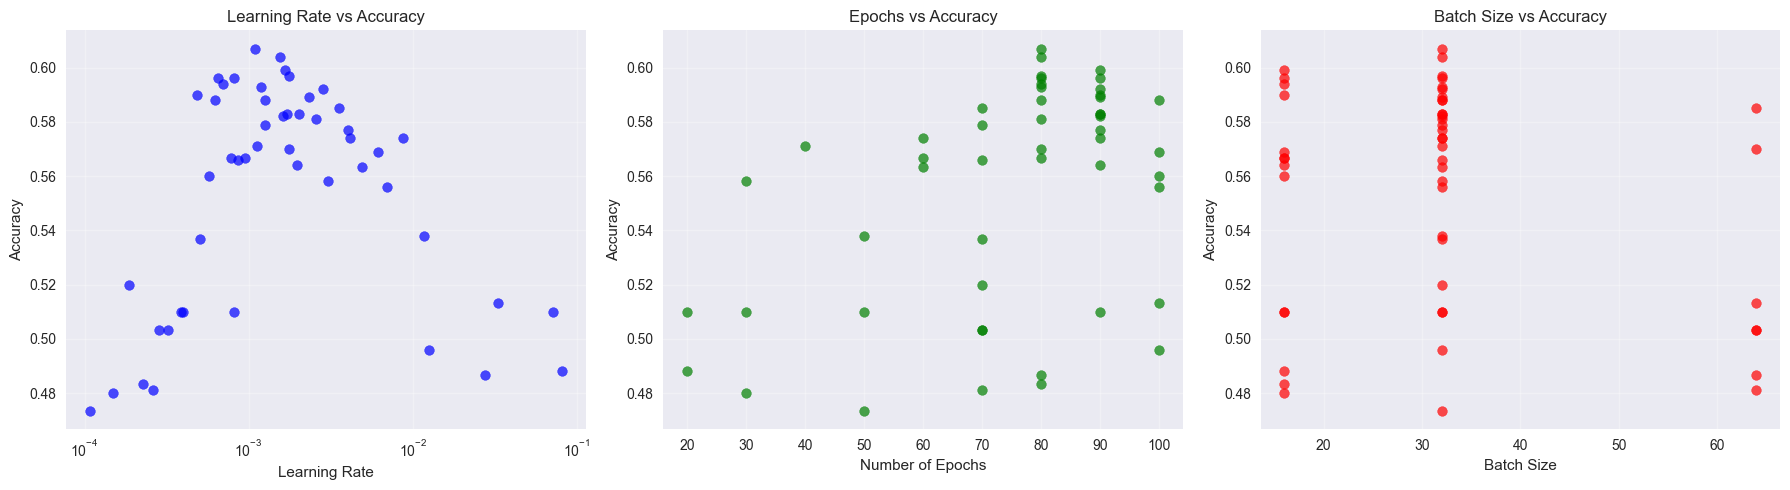


Training final model for detailed evaluation...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


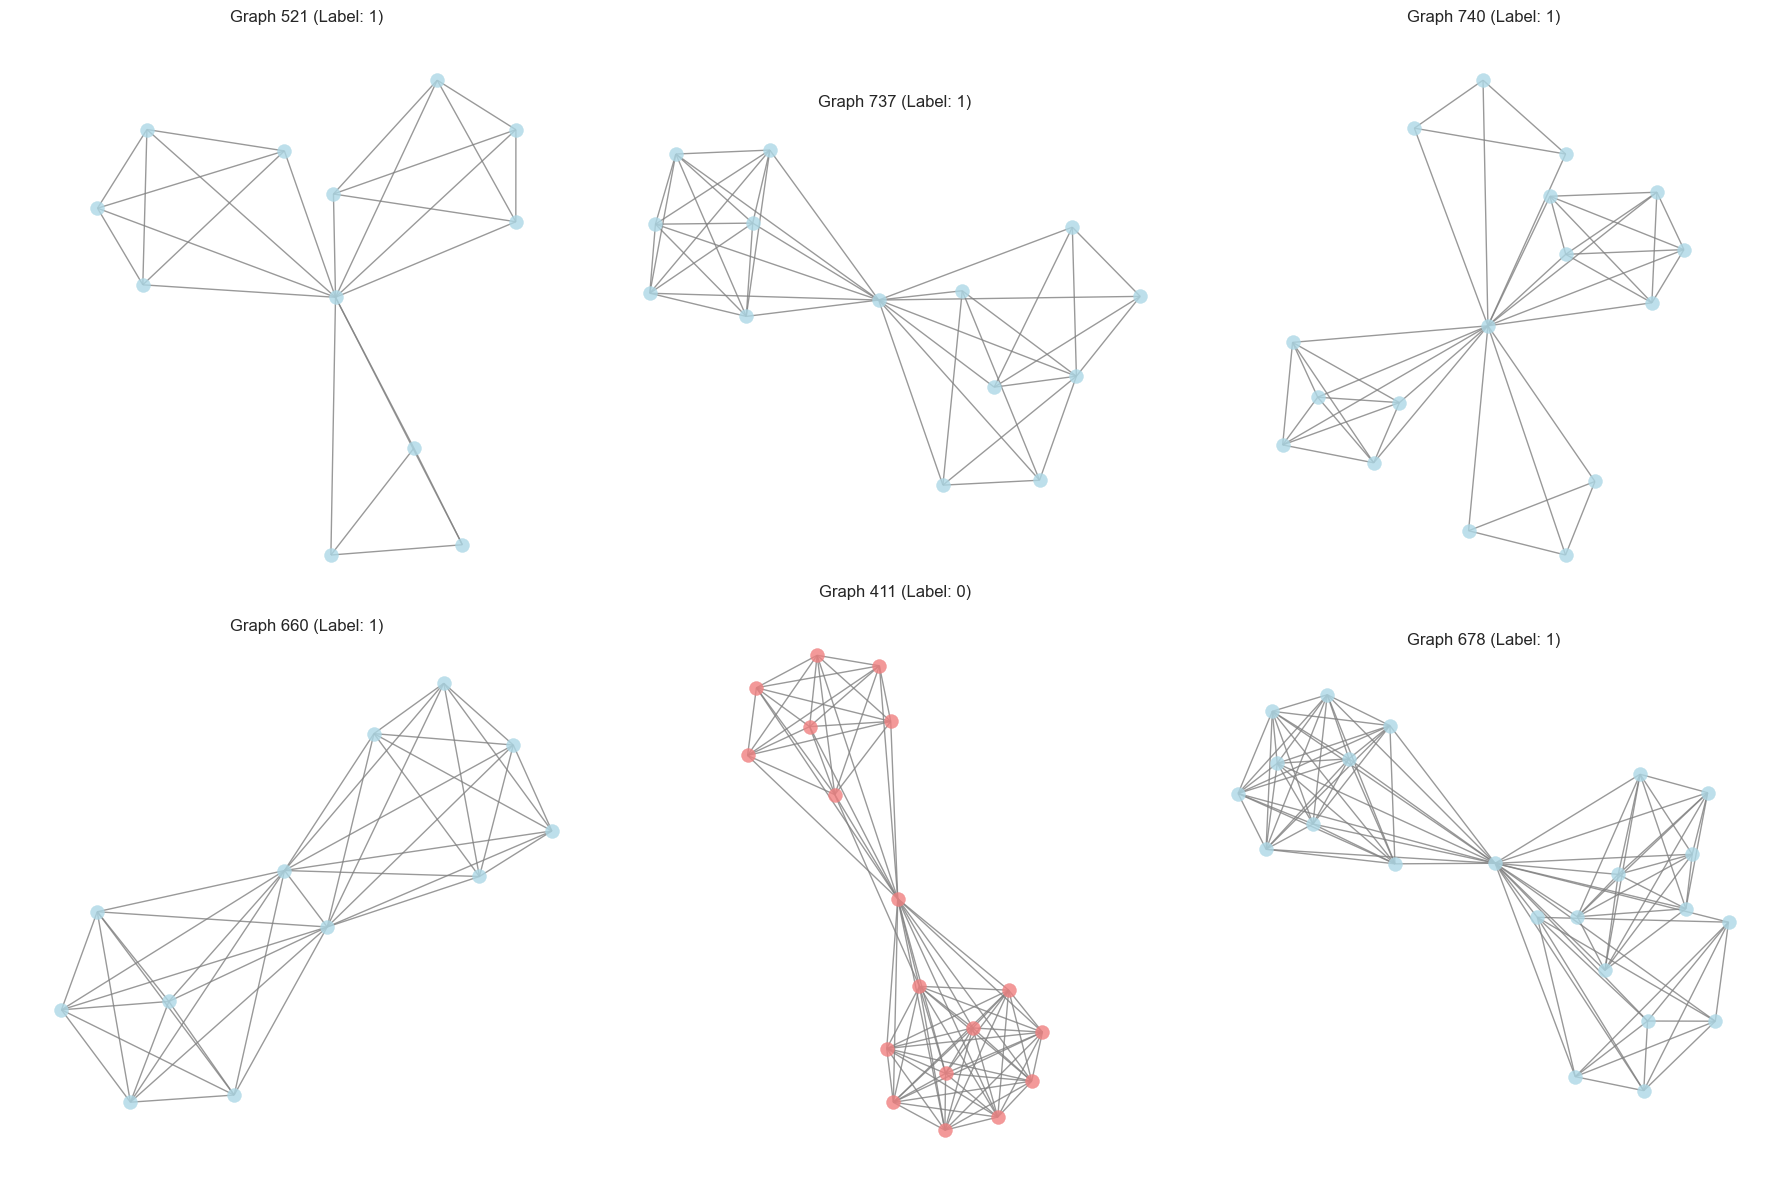

All visualizations have been generated and saved!


In [7]:
# Create visualizer with optimization results
visualizer = GCNResultsVisualizer(
    study=study, 
    all_results=all_results, 
    best_params=study.best_trial.params
)

# Generate core optimization visualizations
visualizer.plot_optimization_history()
visualizer.plot_hyperparameter_relationships()
#visualizer.plot_cross_validation_results()

# For the final model evaluation with the best parameters
print("\nTraining final model for detailed evaluation...")

# Use the entire dataset for final model evaluation
final_train_loader = DataLoader(full_graph_data, batch_size=final_batch_size, shuffle=True)
final_model = GraphNeuralNetwork(input_dim, hidden_dim, output_dim).to(device)
final_optimizer = optim.Adam(final_model.parameters(), lr=final_learning_rate)
final_criterion = nn.CrossEntropyLoss()

# Train the final model
for epoch in range(final_num_epochs):
    train_loss = train_model(final_model, final_train_loader, final_optimizer, final_criterion, device)

# Get predictions and probabilities for visualization
final_y_true, final_y_scores = get_model_probabilities(final_model, final_train_loader, device)
final_y_pred = np.argmax(final_y_scores, axis=1) * 2 - 1  # Convert back to {-1, 1}

# Generate performance visualizations
#visualizer.plot_confusion_matrix(final_y_true, final_y_pred)
#visualizer.plot_roc_curve(final_y_true, final_y_scores)

# Visualize sample graphs
visualizer.plot_sample_graphs(graphs_list, labels_list)

print("All visualizations have been generated and saved!")